# Task 1: Working with data in Python

In this unit we will focus on how to deal with data in Python. The first part involves elementary data management operations (e.g., import, conversion, output). In the second we will focus on plotting data. 

In [1]:
import pandas as pd

## Part 1: Data mingling

### 1.1 Construct complete data sets for Chicago and Potsdam for 2015

#### 1.1.1 Chicago

#### Import the data of Chicago based on local time from .csv (01/01/2015-12/31/2015)

In [2]:
# Read the CSV file
CH_15_df = pd.read_csv("data/PV_generation_Chicago_10kW_0loss_2015.csv", 
                       usecols=[1,2,5],  # Select columns 1 (local time), 2 (electricity), and 5 (temperature)
                       skiprows=3,  # Skip rows before header (0-indexed)
                       parse_dates=['local_time'],  # Automatically parse strings in column 0 to DateTime 
                       encoding='latin1')  # Handle non-standard characters; file contains characters like "≤" that are not covered by 'utf-8' (Standard encoding)

# Display the first 10 rows
CH_15_df.head(10)

,local_time,electricity,temperature
0,2014-12-31 18:00:00,0.0,-6.695
1,2014-12-31 19:00:00,0.0,-6.693
2,2014-12-31 20:00:00,0.0,-6.740
3,2014-12-31 21:00:00,0.0,-6.846
4,2014-12-31 22:00:00,0.0,-7.106
5,2014-12-31 23:00:00,0.0,-7.328
6,2015-01-01 00:00:00,0.0,-7.488
7,2015-01-01 01:00:00,0.0,-7.637
8,2015-01-01 02:00:00,0.0,-7.813
9,2015-01-01 03:00:00,0.0,-7.984


All there?

In [3]:
CH_15_df.shape 
# correct output: 8760 rows and 3 columns

(8760, 3)

In [4]:
CH_15_df.tail() # print last 5 rows

,local_time,electricity,temperature
8755,2015-12-31 13:00:00,5.892,-2.205
8756,2015-12-31 14:00:00,2.700,-2.321
8757,2015-12-31 15:00:00,0.678,-2.661
8758,2015-12-31 16:00:00,0.000,-3.462
8759,2015-12-31 17:00:00,0.000,-4.485


>Inspect the imported data. What do you notice? What is yet to be done to compile a complete data set of 2015?

- What do you notice? #########  first data points refer to 2014 local time, last data points are missing 
- What do we need to do to get a complete data set? ######### delete first six rows, add missing data from 2016 UTC

#### Modify data set to include all data points for 2015

In [5]:
CH_16_df = pd.read_csv("data/PV_generation_Chicago_10kW_0loss_2016.csv", 
               usecols=[1,2,5],  # Select columns 2,3,6 (0-indexed)
               skiprows=3,  # Skip rows before header (0-indexed)
               parse_dates=['local_time'],  # Column 0 to DateTime
               encoding='latin1')  # Use appropriate encoding

CH_16_df.head()

,local_time,electricity,temperature
0,2015-12-31 18:00:00,0.0,-5.308
1,2015-12-31 19:00:00,0.0,-5.897
2,2015-12-31 20:00:00,0.0,-6.220
3,2015-12-31 21:00:00,0.0,-6.302
4,2015-12-31 22:00:00,0.0,-6.056


In [6]:
# Append the data
CH_df = pd.concat([CH_15_df.iloc[6:], CH_16_df.iloc[:6]], ignore_index=True)

# 'reset_index': index aligns with the new concatenated dataframe

# Display the last 10 rows
CH_df.tail(10)

,local_time,electricity,temperature
8750,2015-12-31 14:00:00,2.700,-2.321
8751,2015-12-31 15:00:00,0.678,-2.661
8752,2015-12-31 16:00:00,0.000,-3.462
8753,2015-12-31 17:00:00,0.000,-4.485
8754,2015-12-31 18:00:00,0.000,-5.308
8755,2015-12-31 19:00:00,0.000,-5.897
8756,2015-12-31 20:00:00,0.000,-6.220
8757,2015-12-31 21:00:00,0.000,-6.302
8758,2015-12-31 22:00:00,0.000,-6.056
8759,2015-12-31 23:00:00,0.000,-5.947


Answer:

    Subsections of two dataframes, CH_15_df and CH_16_df, are selected. From CH_15_df, rows from the 7th onward are selected. From CH_16_df, the first 6 rows are selected.

    These two subsections of the dataframes are then concatenated, or joined together vertically, to form a new dataframe CH_df.

    The ignore_index=True parameter is used, which means that the new dataframe CH_df will not retain the original index values from CH_15_df and CH_16_df. Instead, it will have a new set of index values starting from 0, incrementing by 1 for each row.

#### 1.1.2 Potsdam 

#### Import the data of Potsdam based on local time from .csv (01/01/2015-12/31/2015)

>Take a look at the .csv file. What do you notice?

German format using ; and , instead of , and .!!!

In [7]:
# Read the CSV file
P_15_df = pd.read_csv(
    "data/PV_generation_Potsdam_10kW_0loss_2015_GermanFormat.csv", 
    usecols=[1, 2, 5],  # Select columns 2, 3, 6 (0-indexed in Python)
    skiprows=3,  # Skip the first 3 rows (header starts at the 4th row in Python)
    delimiter=';',  # Use semicolon as delimiter
    decimal=',',  # Use comma as decimal separator
    parse_dates=["local_time"], # determine where to find the time data
    date_parser=lambda x: pd.to_datetime(x, format="%d.%m.%Y %H:%M") # Trick to cope with the german date format
)

# Display the first 5 rows of the DataFrame
P_15_df.tail(5)

C:\Users\Nico Gärtner\AppData\Local\Temp\ipykernel_13528\790344827.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  P_15_df = pd.read_csv(


,local_time,electricity,temperature
8755,2015-12-31 20:00:00,0.0,0.225
8756,2015-12-31 21:00:00,0.0,0.223
8757,2015-12-31 22:00:00,0.0,0.271
8758,2015-12-31 23:00:00,0.0,0.197
8759,2016-01-01 00:00:00,0.0,0.024


All there?

In [8]:
P_15_df.shape
# correct output: 8760 rows and 3 columns

(8760, 3)

In [9]:
P_15_df.tail()

,local_time,electricity,temperature
8755,2015-12-31 20:00:00,0.0,0.225
8756,2015-12-31 21:00:00,0.0,0.223
8757,2015-12-31 22:00:00,0.0,0.271
8758,2015-12-31 23:00:00,0.0,0.197
8759,2016-01-01 00:00:00,0.0,0.024


#### Modify data set to include all data points for 2015

In [10]:
# Read the CSV file into a DataFrame
P_14_df = pd.read_csv(
    "data/PV_generation_Potsdam_10kW_0loss_2014_GermanFormat.csv",
    usecols=[1, 2, 5],
    skiprows=3,
    delimiter=';',
    decimal=',',
    parse_dates=["local_time"],
    date_parser=lambda x: pd.to_datetime(x, format="%d.%m.%Y %H:%M")
)

P_14_df.tail(10)

C:\Users\Nico Gärtner\AppData\Local\Temp\ipykernel_13528\179866899.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  P_14_df = pd.read_csv(


,local_time,electricity,temperature
8750,2014-12-31 15:00:00,0.0,1.192
8751,2014-12-31 16:00:00,0.0,1.325
8752,2014-12-31 17:00:00,0.0,1.500
8753,2014-12-31 18:00:00,0.0,1.571
8754,2014-12-31 19:00:00,0.0,1.645
8755,2014-12-31 20:00:00,0.0,1.692
8756,2014-12-31 21:00:00,0.0,1.722
8757,2014-12-31 22:00:00,0.0,1.638
8758,2014-12-31 23:00:00,0.0,1.654
8759,2015-01-01 00:00:00,0.0,1.667


In [11]:
# Concatenate the last row of P_14_df and all but the last row of P_15_df
P_df = pd.concat([P_14_df.iloc[-1:], P_15_df.iloc[:-1]], ignore_index=True)

# Display the last 10 rows
P_df.head(10)

,local_time,electricity,temperature
0,2015-01-01 00:00:00,0.000,1.667
1,2015-01-01 01:00:00,0.000,1.574
2,2015-01-01 02:00:00,0.000,1.470
3,2015-01-01 03:00:00,0.000,1.294
4,2015-01-01 04:00:00,0.000,1.139
5,2015-01-01 05:00:00,0.000,0.949
6,2015-01-01 06:00:00,0.000,0.577
7,2015-01-01 07:00:00,0.000,0.361
8,2015-01-01 08:00:00,0.006,0.313
9,2015-01-01 09:00:00,0.323,0.611


In [12]:
P_df.tail()

,local_time,electricity,temperature
8755,2015-12-31 19:00:00,0.0,0.332
8756,2015-12-31 20:00:00,0.0,0.225
8757,2015-12-31 21:00:00,0.0,0.223
8758,2015-12-31 22:00:00,0.0,0.271
8759,2015-12-31 23:00:00,0.0,0.197


Are `CH_df` and `P_df` the same size?

In [13]:
CH_df.shape, P_df.shape

((8760, 3), (8760, 3))

### 1.2 Merge both datasets and export to .csv file

In [14]:
# How to convert 'local_time' to datetime manually
#CH_df['local_time'] = pd.to_datetime(CH_df['local_time'], errors='coerce')
#P_df['local_time'] = pd.to_datetime(P_df['local_time'], errors='coerce')

# 'inner' join ensures that only data is included that is part of both DataFrames
# 'local_time' columns in each DataFrame have to be the same type
df = pd.merge(CH_df, P_df, on='local_time', how='inner')

# Display the first 5 rows
df.head()

,local_time,electricity_x,temperature_x,electricity_y,temperature_y
0,2015-01-01 00:00:00,0.0,-7.488,0.0,1.667
1,2015-01-01 01:00:00,0.0,-7.637,0.0,1.574
2,2015-01-01 02:00:00,0.0,-7.813,0.0,1.470
3,2015-01-01 03:00:00,0.0,-7.984,0.0,1.294
4,2015-01-01 04:00:00,0.0,-8.147,0.0,1.139


In [15]:
df.columns = ['time', 'CH_PV', 'CH_temp', 'P_PV', 'P_temp']  # rename the columns

df.head()  # display the first 5 rows

,time,CH_PV,CH_temp,P_PV,P_temp
0,2015-01-01 00:00:00,0.0,-7.488,0.0,1.667
1,2015-01-01 01:00:00,0.0,-7.637,0.0,1.574
2,2015-01-01 02:00:00,0.0,-7.813,0.0,1.470
3,2015-01-01 03:00:00,0.0,-7.984,0.0,1.294
4,2015-01-01 04:00:00,0.0,-8.147,0.0,1.139


In [16]:
df.shape

(8760, 5)

Create or overwrite a .csv file at `data/pv_temp_both.csv` with `to_csv`


In [17]:
df.to_csv("data/pv_temp_both.csv", index=False) # 'index=False' excludes the row index from being written to the CSV file.

>#### What's the issue when concatenating both DataFrames?

There's an issue with handling the `daylight saving time (DST)` in the data.

Daylight Saving Time is the practice of setting the clock ahead by one hour during the warmer part of the year, so evenings have more daylight and mornings have less. The dates when DST starts and ends can vary between regions or countries. In this case, Chicago (CH) and Potsdam (P) transition to and from DST on different dates.

When merging or comparing datasets from these two locations based on local time, the data may become misaligned during the periods when one location has switched to or from DST but the other has not.

The proposed workaround is to merge the datasets based on Coordinated Universal Time (UTC) instead of local time. UTC does not change with DST. After merging, the local times can be recalculated as needed.

`DST will be ignored in further consideration!`


### 1.3. Calculate monthly mean values

Add column with month indicator

In [18]:
df['month'] = df['time'].dt.month # only possible, when "df['time']" is a DateTime Obj.

# The dt accessor is used to access the datetime properties of a pandas Series or DataFrame column. 
# In this case, dt.month is used to extract the month component from the column 'time'.

In [19]:
df.head()

,time,CH_PV,CH_temp,P_PV,P_temp,month
0,2015-01-01 00:00:00,0.0,-7.488,0.0,1.667,1
1,2015-01-01 01:00:00,0.0,-7.637,0.0,1.574,1
2,2015-01-01 02:00:00,0.0,-7.813,0.0,1.470,1
3,2015-01-01 03:00:00,0.0,-7.984,0.0,1.294,1
4,2015-01-01 04:00:00,0.0,-8.147,0.0,1.139,1


In [20]:
df.columns[1] # get name of column 2 (0-indexed)

'CH_PV'

First, let's create a new DataFrame `df_mean` where you can find the mean for `CH_PV` for each month.

In [21]:
# Calculate monthly mean values

df_mean = df.groupby('month')['CH_PV'].mean().reset_index() 

# groups the DataFrame df by the 'month' column and calculates the mean of 'CH_PV' column within each group. 

df_mean # Display df_mean

,month,CH_PV
0,1,1.346243
1,2,1.730405
2,3,2.253500
3,4,2.228213
4,5,2.100133
5,6,2.181668
6,7,2.319815
7,8,2.287159
8,9,2.025211
9,10,1.759021


Rename the column to `CH_PV_mean`

In [22]:
# Rename the column
df_mean.rename(columns={"CH_PV": "CH_PV_mean"}, inplace=True) # inplace=True modifies the DataFrame df_mean directly, without the need to assign the result back to a new variable.

# Display the DataFrame
df_mean

,month,CH_PV_mean
0,1,1.346243
1,2,1.730405
2,3,2.253500
3,4,2.228213
4,5,2.100133
5,6,2.181668
6,7,2.319815
7,8,2.287159
8,9,2.025211
9,10,1.759021


Now, let's overwrite and rename the DataFrame `df_mean` so you can find the mean values for `'CH_PV', 'CH_temp', 'P_PV', 'P_temp'` for each month. (same procedure)

In [23]:
# Define new DataFrame based on aggregation by month
df_mean = df.groupby('month')[['CH_PV', 'CH_temp', 'P_PV', 'P_temp']].mean().reset_index()

# Rename the columns
df_mean.rename(columns={
    "CH_PV": "CH_PV_mean", 
    "CH_temp": "CH_temp_mean",
    "P_PV": "P_PV_mean",
    "P_temp": "P_temp_mean"}, inplace=True)

# Display the DataFrame
df_mean

,month,CH_PV_mean,CH_temp_mean,P_PV_mean,P_temp_mean
0,1,1.346243,-4.393263,0.364073,1.424409
1,2,1.730405,-8.568528,1.211469,0.173976
2,3,2.253500,0.791311,1.395296,4.593698
3,4,2.228213,7.931176,1.996989,7.845300
4,5,2.100133,14.289149,2.256767,12.186503
5,6,2.181668,18.081364,2.213754,15.788471
6,7,2.319815,21.656097,2.320565,19.337390
7,8,2.287159,21.950774,2.095269,20.978305
8,9,2.025211,20.196414,1.775532,13.511504
9,10,1.759021,12.668169,1.106458,7.472549


We can transform the DataFrame back to a matrix (= 2D NumPy Array) with `.to_numpy()`

In [24]:
matrix_df_mean = df_mean.to_numpy() # convert a DataFrame to a numpy array

matrix_df_mean

array([[ 1.        ,  1.34624328, -4.39326344,  0.36407258,  1.4244086 ],
       [ 2.        ,  1.73040476, -8.56852827,  1.21146875,  0.17397619],
       [ 3.        ,  2.2535    ,  0.79131132,  1.3952965 ,  4.59369811],
       [ 4.        ,  2.2282125 ,  7.93117639,  1.99698889,  7.8453    ],
       [ 5.        ,  2.10013306, 14.28914919,  2.25676747, 12.18650269],
       [ 6.        ,  2.18166806, 18.08136389,  2.21375417, 15.78847083],
       [ 7.        ,  2.31981452, 21.65609677,  2.32056452, 19.33738978],
       [ 8.        ,  2.2871586 , 21.95077419,  2.09526882, 20.97830511],
       [ 9.        ,  2.02521111, 20.19641389,  1.77553194, 13.51150417],
       [10.        ,  1.75902148, 12.66816913,  1.10645772,  7.47254899],
       [11.        ,  1.54618863,  7.66835229,  0.56311928,  6.35873232],
       [12.        ,  0.94143952,  3.76062097,  0.4136828 ,  5.19702688]])

### 1.4 Save to .csv file

In [25]:
df_mean.to_csv("data/pv_temp_monthly_mean.csv", index=False)

# 'index=False' prevents pandas from writing row indices into the CSV file

Break ☕😎

## Part 2: Visualization

In [26]:
#In case you haven't done so, let's import our libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### 2.1 Visualize monthly mean values

In [27]:
df_mean = pd.read_csv("data/pv_temp_monthly_mean.csv") # Import data from .csv into DataFrame (if no longer available from Task 1)

In [28]:
df_mean # print result

,month,CH_PV_mean,CH_temp_mean,P_PV_mean,P_temp_mean
0,1,1.346243,-4.393263,0.364073,1.424409
1,2,1.730405,-8.568528,1.211469,0.173976
2,3,2.253500,0.791311,1.395296,4.593698
3,4,2.228213,7.931176,1.996989,7.845300
4,5,2.100133,14.289149,2.256767,12.186503
5,6,2.181668,18.081364,2.213754,15.788471
6,7,2.319815,21.656097,2.320565,19.337390
7,8,2.287159,21.950774,2.095269,20.978305
8,9,2.025211,20.196414,1.775532,13.511504
9,10,1.759021,12.668169,1.106458,7.472549


#### Let's create a combined chart of the PV generation and temperature of each month

In [29]:
x = np.array(range(1,13)) # Create x values (months)
x # display

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [30]:
# Extract PV and temperature values
PV_mean = df_mean[['CH_PV_mean', 'P_PV_mean']].to_numpy() # convert DF to 2D NumPy Array
T_mean = df_mean[['CH_temp_mean', 'P_temp_mean']].to_numpy() # convert DF to 2D NumPy Array

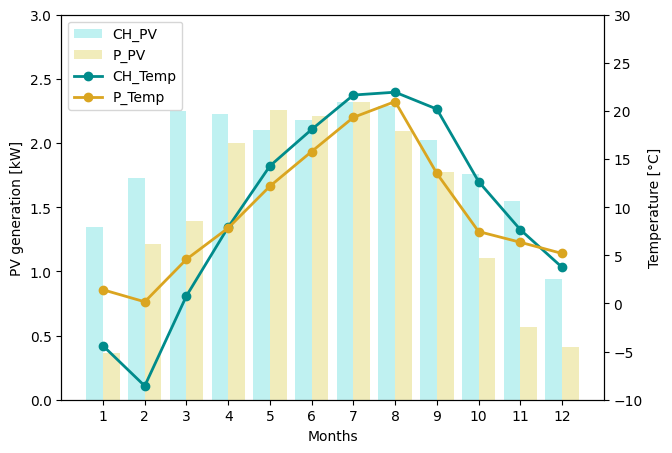

In [31]:
# Import the necessary library
import matplotlib.pyplot as plt

# Create a figure and a set of subplots; the figure is the "canvas" on which the chart will be generated.
# figsize=(7,5) sets the width to 7 inches and height to 5 inches of the figure.
fig, ax1 = plt.subplots(figsize=(7,5)) 

# First Axis: Bar Chart for PV Generation
# Bar chart showing the mean PV generation for two categories (CH_PV and P_PV)
# x - 0.2 and x + 0.2 adjust the positions of the two bar graphs (for 'CH_PV' and 'P_PV') to be side by side.
# PV_mean[:, 0] and PV_mean[:, 1] represent the data values to be plotted.
# 0.4 is the width of the bars.
ax1.bar(x - 0.2, PV_mean[:, 0], 0.4, label='CH_PV', color='paleturquoise', alpha=0.8)
ax1.bar(x + 0.2, PV_mean[:, 1], 0.4, label='P_PV', color='palegoldenrod', alpha=0.8)

# Labelling x-axis as 'Months' and y-axis as 'PV generation [kW]'
ax1.set_xlabel('Months')
ax1.set_ylabel('PV generation [kW]')

# Setting the limits for the x-axis and y-axis manually
ax1.set_xlim(0, 13)
ax1.set_ylim(0, 3)

# Setting the x-axis ticks to match the month numbers.
ax1.set_xticks(x)
#or more general
#ax1.set_xticks(np.arange(min(x), max(x)+1, 1.0))

# Second Axis: Line Graph for Temperature
# Creating a second y-axis (ax2) for plotting temperature, which shares the same x-axis as ax1.
# This is useful for overlaying graphs with different y-axis scales.
ax2 = ax1.twinx()

# Line graph showing mean temperature for two categories (CH_Temp and P_Temp) using markers and different colors
ax2.plot(x, T_mean[:, 0], color='darkcyan', linewidth=2, marker='o', label='CH_Temp')
ax2.plot(x, T_mean[:, 1], color='goldenrod', linewidth=2, marker='o', label='P_Temp')

# Labelling and setting the limits for the second y-axis
ax2.set_ylabel('Temperature [°C]')
ax2.set_ylim(-10, 30)

# Combining Legends from Both Axes
# Retrieving line and label data for legends from both axes
# get_legend_handles_labels() retrieves the legend handles and labels from the ax1 and ax2.
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Combining legends from both ax1 and ax2, positioning them on the upper left of the plot
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Display the entire Plot
plt.show()

In [32]:
fig.savefig("figures/PV_temp_monthly_means.pdf")
# or as PNG: fig.savefig("figures/PV_temp_monthly_means.png")

### 2.2 Visualize confidence intervals

Load the initial merged DataFrame and add a column for the hour

In [33]:
# Read the CSV file into a DataFrame
df = pd.read_csv("data/pv_temp_both.csv", parse_dates=['time'])

# Add a new column 'hour' with information on the hour of the day
df['hour'] = df['time'].dt.hour

# Display the first 5 rows of the DataFrame
df.head()

,time,CH_PV,CH_temp,P_PV,P_temp,hour
0,2015-01-01 00:00:00,0.0,-7.488,0.0,1.667,0
1,2015-01-01 01:00:00,0.0,-7.637,0.0,1.574,1
2,2015-01-01 02:00:00,0.0,-7.813,0.0,1.470,2
3,2015-01-01 03:00:00,0.0,-7.984,0.0,1.294,3
4,2015-01-01 04:00:00,0.0,-8.147,0.0,1.139,4


Chicago DataFrame with median values

In [34]:
# PV quantiles
df_CH = df.groupby('hour')['CH_PV'].median().reset_index()  # Calculate median values for Chicago and write to new DataFrame df_CH

In [35]:
df_CH

,hour,CH_PV
0,0,0.000
1,1,0.000
2,2,0.000
3,3,0.000
4,4,0.000
5,5,0.000
6,6,0.000
7,7,0.870
8,8,2.670
9,9,4.447


Now the complete Chicago DataFrame with median values and confidence intervals

In [36]:
# PV quantiles
df_CH = df.groupby('hour')['CH_PV'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
df_CH.columns = ['hour', 'CH_PV_median', 'CH_PV_25_quant', 'CH_PV_75_quant']

# add temperature indicators
df_temp = df.groupby('hour')['CH_temp'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
df_temp.columns = ['hour', 'CH_Temp_median', 'CH_Temp_25_quant', 'CH_Temp_75_quant']

# join two dataframes
df_CH = pd.merge(df_CH, df_temp, on='hour')

df_CH

,hour,CH_PV_median,CH_PV_25_quant,CH_PV_75_quant,CH_Temp_median,CH_Temp_25_quant,CH_Temp_75_quant
0,0,0.000,0.000,0.000,9.1740,1.19100,16.9790
1,1,0.000,0.000,0.000,8.8735,0.86100,16.7890
2,2,0.000,0.000,0.000,8.6670,0.79975,16.5235
3,3,0.000,0.000,0.000,8.2930,0.53800,16.0150
4,4,0.000,0.000,0.000,7.9830,0.56000,15.9160
5,5,0.000,0.000,0.000,7.7680,0.48000,15.8640
6,6,0.000,0.000,0.279,7.9660,0.49400,15.9180
7,7,0.870,0.287,1.605,8.4730,0.61900,16.7010
8,8,2.670,1.482,3.764,9.6860,1.48500,17.6840
9,9,4.447,2.748,5.730,10.7800,2.57000,18.9240


Now for Potsdam: DataFrame with median values and quantiles

In [37]:
# PV quantiles
df_P = df.groupby('hour')['P_PV'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
df_P.columns = ['hour', 'P_PV_median', 'P_PV_25_quant', 'P_PV_75_quant']

# Temperature quantiles
df_temp = df.groupby('hour')['P_temp'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
df_temp.columns = ['hour', 'P_Temp_median', 'P_Temp_25_quant', 'P_Temp_75_quant']

# join two dataframes
df_P = pd.merge(df_P, df_temp, on='hour')

df_P

,hour,P_PV_median,P_PV_25_quant,P_PV_75_quant,P_Temp_median,P_Temp_25_quant,P_Temp_75_quant
0,0,0.000,0.000,0.000,7.2370,2.256,11.80400
1,1,0.000,0.000,0.000,6.8365,2.210,11.38350
2,2,0.000,0.000,0.000,6.4720,1.864,10.82325
3,3,0.000,0.000,0.000,6.0510,1.820,10.51300
4,4,0.000,0.000,0.000,5.7120,1.710,9.97100
5,5,0.000,0.000,0.000,5.6880,1.572,10.00300
6,6,0.000,0.000,0.286,6.0110,1.590,10.54400
7,7,0.319,0.000,1.243,6.8530,1.698,11.67400
8,8,1.433,0.241,2.788,7.4790,2.369,13.10700
9,9,2.962,0.974,4.625,8.9670,3.894,14.77400


In [38]:
# convert DataFrame to arrays
h = df_CH['hour'].values
y_CH = df_CH.drop('hour', axis=1).values
y_P = df_P.drop('hour', axis=1).values

Create visualization

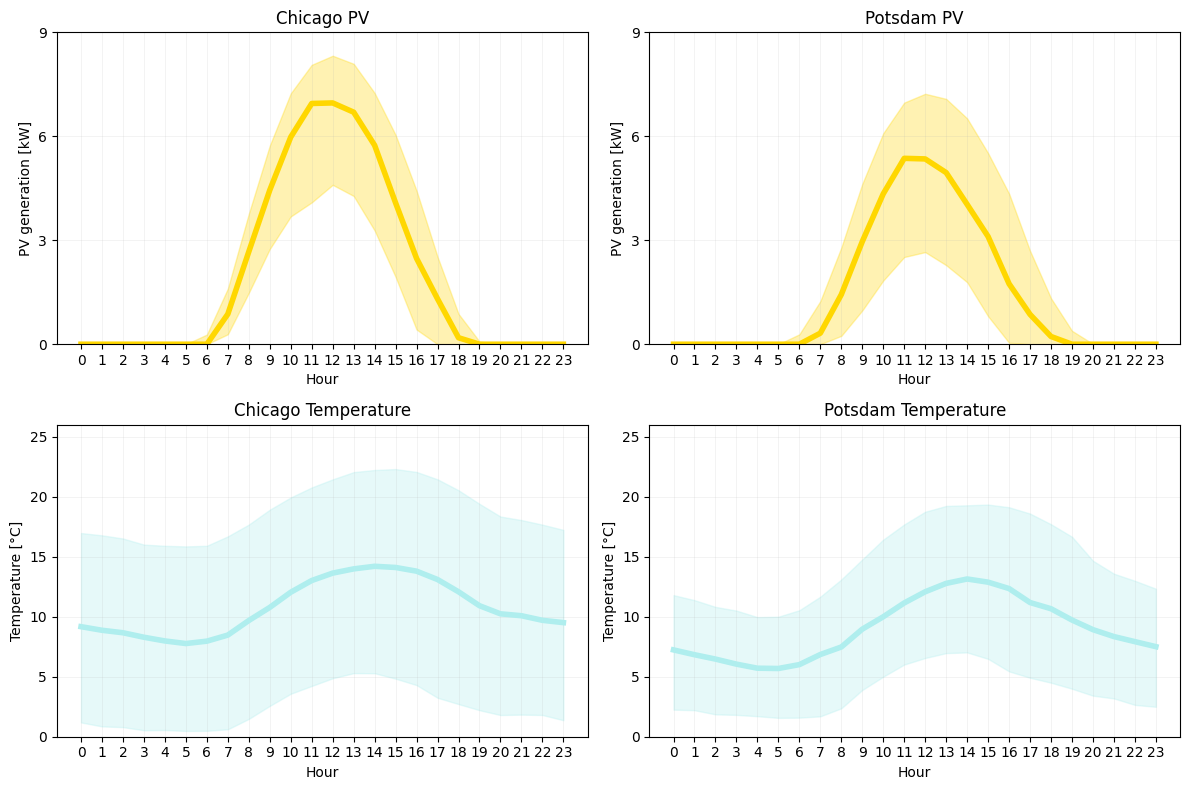

In [39]:
import matplotlib.pyplot as plt

# Set common limits of y-axis to compare the plots
PV_ymax = 9
Temp_ymax = 26

# Initialize a 2x2 subplot figure
fig, axs = plt.subplots(2, 2, figsize=(12,8)) # use 'axs' when creating a figure with multiple subplots

# Chicago PV
axs[0, 0].fill_between(h, y_CH[:,2], y_CH[:,1], color='gold', alpha=0.3)
axs[0, 0].plot(h, y_CH[:,0], color='gold', linewidth=4.0)
axs[0, 0].set_ylim(0, PV_ymax)
axs[0, 0].set_yticks(np.arange(0, 10, 3.0))
axs[0, 0].set_xticks(np.arange(0, 24, 1.0))
axs[0, 0].set_title('Chicago PV')
axs[0, 0].set_ylabel('PV generation [kW]')
axs[0, 0].set_xlabel('Hour')
axs[0, 0].grid(linewidth=0.5, alpha=0.2)

# Potsdam PV
axs[0, 1].fill_between(h, y_P[:,2], y_P[:,1], color='gold', alpha=0.3)
axs[0, 1].plot(h, y_P[:,0], color='gold', linewidth=4.0)
axs[0, 1].set_ylim(0, PV_ymax)
axs[0, 1].set_yticks(np.arange(0, 10, 3.0))
axs[0, 1].set_xticks(np.arange(0, 24, 1.0))
axs[0, 1].set_title('Potsdam PV')
axs[0, 1].set_ylabel('PV generation [kW]')
axs[0, 1].set_xlabel('Hour')
axs[0, 1].grid(linewidth=0.5, alpha=0.2)

# Chicago Temperature
axs[1, 0].fill_between(h, y_CH[:,5], y_CH[:,4], color='paleturquoise', alpha=0.3)
axs[1, 0].plot(h, y_CH[:,3], color='paleturquoise', linewidth=4.0)
axs[1, 0].set_ylim(0, Temp_ymax)
axs[1, 0].set_xticks(np.arange(0, 24, 1.0))
axs[1, 0].set_ylabel('Temperature [°C]')
axs[1, 0].set_title('Chicago Temperature')
axs[1, 0].set_xlabel('Hour')
axs[1, 0].grid(linewidth=0.5, alpha=0.2)

# Potsdam Temperature
axs[1, 1].fill_between(h, y_P[:,5], y_P[:,4], color='paleturquoise', alpha=0.3)
axs[1, 1].plot(h, y_P[:,3], color='paleturquoise', linewidth=4.0)
axs[1, 1].set_ylim(0, Temp_ymax)
axs[1, 1].set_xticks(np.arange(0, 24, 1.0))
axs[1, 1].set_ylabel('Temperature [°C]')
axs[1, 1].set_title('Potsdam Temperature')
axs[1, 1].set_xlabel('Hour')
axs[1, 1].grid(linewidth=0.5, alpha=0.2)

# Adjust layout for neat appearance
plt.tight_layout()
plt.show()


In [40]:
# save figure
fig.savefig('figures/PV_temp_daily_confidence.pdf')

done 👍